# **Tarea Mecánica Teórica.**
## Parcial 1: Solución numérica oscilador paramétrico.


### Yuliana Guerrero Uchima
### Dayana Andrea Henao Arbelaez

En el presente se encuentra contenida la tarea correspondiente a la primera sección del curso de Mecánica Teórica en el semestre 2022-1, cuyo contenido respecta a las oscilaciones pequeñas. El tema elegido para el desarrollo de esta tarea fue el **oscilador paramétrico: Solución numérica cuando la frecuencia varía en forma de "onda cuadrada" o "diente de sierra"**; en el caso específico de una señal cuya frecuencia forzante varía en forma de onda cuadrada. El presente archivo fue desarrollado como un documento de tipo cuaderno de Python, para su correcta visualización se requieren las imágenes adjuntas en el archivo comprimido.

A continuación, se presenta el código inicial correspondiente a librerías, parámetros de gráficas y la formulación de la señal junto a sus parámetros. Los códigos mostrados poseen los comentarios necesarios y suficientes para su comprensión, en caso de requerir más información se puede solicitar. Más adelante se expondrá la explicación teórica, apoyada en la bibliografía presentada.

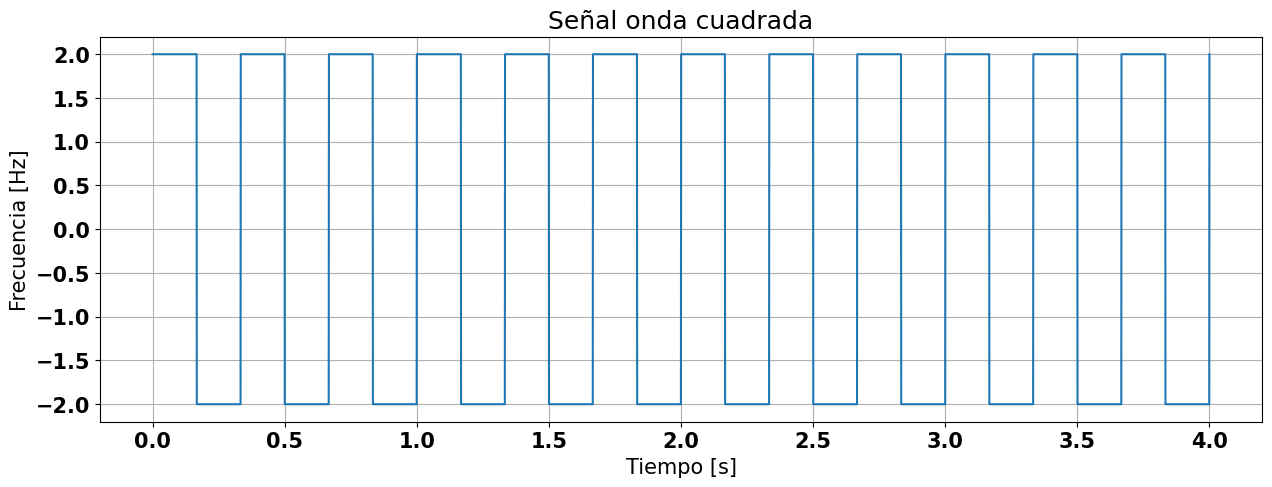

In [ ]:
# Librerías necesarias para el desarrollo del código.

import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
import scipy.stats as stats
from scipy.integrate import simps
import matplotlib
from matplotlib import cm
from math import *
from scipy.integrate import odeint

# Parámetros de gráfica.

plt.rcParams['figure.figsize'] = 15, 5 #ancho, alto
font = {'weight' : 'bold',
        'size'   : 15}
matplotlib.rc('font', **font)

# Definición y generación de la señal cuadrada.

# Parámetros de la señal.
a = 0 # Tiempo de inicio de la señal [s].
b = 4 # Tiempo final de la señal [s].
dt = 5000 # Cantidad de puntos para partición temporal.
f = 3 # Frecuencia de la señal [Hz].
t = np.linspace(a, b, dt) # Arreglo para el tiempo de la señal.
#sig = np.sin(2*np.pi*t) # Señal seno para ciclo de trabajo posterior.

signal = 2*(signal.square(2*np.pi*f*t)) # Señal cuadrada, usando función de scipy.

# La señal puede ser cambiada por cualquier otra, como una diente de sierra, coseno o cualquiera.

# Gráfica de la señal.
plt.plot(t,signal)
plt.title('Señal onda cuadrada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.grid()
plt.show()

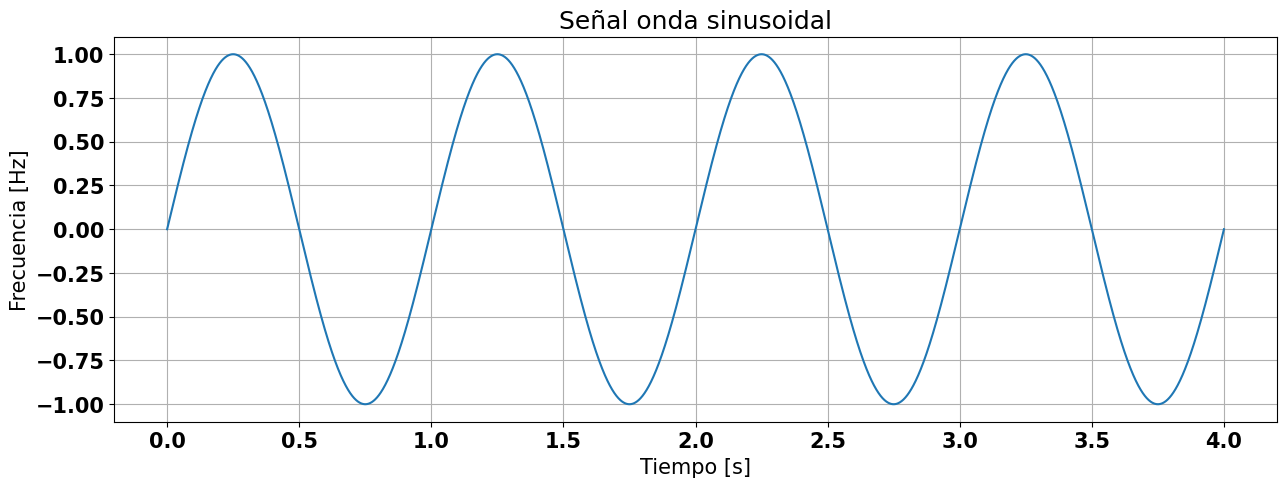

In [ ]:
sig = np.sin(2*np.pi*t) # Señal seno para ciclo de trabajo posterior.

#signal = 2*(signal.square(2*np.pi*f*t)) # Señal cuadrada, usando función de scipy.

# La señal puede ser cambiada por cualquier otra, como una diente de sierra, coseno o cualquiera.

# Gráfica de la señal.
plt.plot(t,sig)
plt.title('Señal onda sinusoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.grid()
plt.show()

### Fundamento Teórico.

La resonancia paramétrica se da en sistemas oscilantes no cerrados, teniendo como resultado de una acción exterior la variación en el tiempo de los parámetros del sistema. Esos sistemas se encuentran caracterizados por la ecuación [1]:

$$\ddot{x}+\omega^{2}x=0$$

Donde $\omega^{2}=\omega_{0}^{2}\left[1+h\cos\gamma \right] \text{; cuando } x = 0$. Luego, se sigue la siguiente ecuación diferencial:

$$\boxed{\ddot{x}+\omega_{0}^{2}\left[1+h\cos(\gamma t ) \text{} \right]x=0}$$

La frecuencia para variar se expresa en términos de $\gamma$ en la ecuación anterior. En este caso, la acción exterior debe tratarse de una función periódica, en el caso particular comouna funcion cuadratica y una diente de sierra. Como solución a la ecuación de movimiento previa se tiene su forma matricial:

$$X = \begin{bmatrix}
   x \\
\dot{x}    
\end{bmatrix}=\begin{bmatrix}
   X[0] \\
X[1]    
\end{bmatrix}; \quad \frac{dX}{dt} = \begin{bmatrix}
   \dot{x} \\
\ddot{x}    
\end{bmatrix}=\begin{bmatrix}
   \dot{x} \\
    -\omega_{0}^{2}\left[1+h\cos \gamma t\right]x
\end{bmatrix}=\begin{bmatrix}
   X[1] \\
    -\omega_{0}^{2}\left(1+h\cos \gamma t\right)X[0]
\end{bmatrix}$$


Posteriormente este sistema matricial de ecuaciones diferenciales será resuelto de forma computacional, utilizando métodos numéricos existentes en la documentación de *Python* o Runge-Kutta. Luego, existirá resonancia paramétrica en el oscilador si $\gamma$ pertenece al siguiente intervalo, que funciona como condición de este [1]:


$$\left( \frac{2\omega_{0}}{n}-\epsilon,\frac{2\omega_{0}}{n}+\epsilon \right)=\left(\frac{2\omega_{0}}{n}-\frac{n^{2n-3}h^{n}\omega_{0}}{2^{3n-2}[(n-1)!]^{2}} ,\frac{2\omega_{0}}{n}+\frac{n^{2n-3}h^{n}\omega_{0}}{2^{3n-2}[(n-1)!]^{2}}\right)$$

En este caso se tiene un parámetro entero $n$ que se refiere a la proximidad de $\gamma$ con $\omega_0$. Además, el ancho de la región de inestabilidad es:

$$\Delta \epsilon=\frac{n^{2n-3}h^{n}\omega_{0}}{2^{3(n-1)}[(n-1)!]^{2}}$$

Ergo, a medida que $\gamma$ varía, se espera que también varíe la señal cuadrada (o cualquier otra señal periódica), y por ello, en ciertos intervalos pequeños dados por la ecuación previa, se presenta el fenómeno de resonancia paramétrica.

### **Solución y análisis numérico.**

En las siguientes celdas se observa la solución de la ecuación diferencial previa, usando métodos numéricos y computacionales pertenecientes a la documentación de las librerías de *Numpy* y *Scipy* de *Python*. En el primer caso se varía n en pro de buscar los distintos intervalos para los cuales la frecuencia presente resonancia paramétrica. Posterior a ello se realizará un análisis alrededor del cambio de la cantidad de puntos y forma de resonancia según el cambio de $n$ y la elección y fijación arbitraria de los parámetros $h$ (mucho menor a 1) y $\omega_0$ (siempre igual a la amplitud de la señal); revisando los cambios al modificar los parámetros y posibles resultados relevantes.

In [ ]:
# Solución de ecuación diferencial en forma numérica.

# Parámetros de solución.
h = 0.2 # Constante de resonancia.
w = 2 # Frecuencia inicial.

for n in range(1,4): # Probando hasta que n llega la resonancia.

    print('Para un n = ',n, ':')

    delte = (n**(2*n - 3)*(h**n)*w)/((2**(3*(n - 1)))*(factorial(n - 1))**2) # Ancho de inestabilidad.
    sol1 = [] # Lista de solución.

    for i in range(len(t)):
        r = signal[i] # Selección de valor de señal.
        T = t[i] # Selección de tiempos.

        def dX_dt(X,t): # Se define la E.D.O. en forma matricial.
            return [X[1],-(w**2)*(1 + h*np.cos(r*T)*X[0])]

        X0 = [0, 0] # Condicioenes iniciales.
                    # empieza desde el reposo

        # Solución numérica EDO.
        XS1 = odeint(dX_dt,X0,t) # Función de resolución de EDO.
        XS = [] #se guardan las soluciones

        for i in range(len(t)): # Creación de lista solución.
            XS.append([t[i],XS1[i][0],XS1[i][1]])

        XS = np.array(XS)
        X = np.transpose(XS)
        sol1.append(X[1][i]) # Elementos a lista solución.

    # Gráfica de la solución.
    res1 = []
    t1 = []

    for i in range(len(sol1)): # Comprobación de existencia de resonancia.
        if  (((2*w)/n)- delte) < signal[i] < (((2*w)/n)+delte): # Intervalo de resonancia.
            res1.append(sol1[i])
            t1.append(t[i])

    if len(res1) == 0: # Generación de comentarios para verificar condiciones.
        print('Bajo los parámetros ingresados no se presenta resonancia paramétrica, sólo oscilaciones puras.')

    elif len(res1) >= 1:
        print('Existe resonancia paramétrica en algunos intervalos (puntos) de la señal.')

        for i in range(len(t1)):
            plt.plot(t1[i],res1[i], marker="o", color="black")

    plt.plot(t,sol1) # Gráfica de señal tras presentar resonancia paramétrica.
    plt.xlabel('Tiempo [t]')
    plt.ylabel('Intensidad [a.u.]')
    plt.grid()
    plt.title('Oscilación forzada bajo señal implementada')
    plt.show()

    # Gráfica de la señal original indicando aquellos valores que presentan resonancia paramétrica.
    res = []
    t2 = []

    for i in range(len(signal)):
        if  (((2*w)/n) -delte) < signal[i] < (((2*w)/n) + delte):
            res.append(signal[i])
            t2.append(t[i])

    for i in range(len(t1)):
        plt.plot(t2[i],res[i], marker="o", color="black")

    plt.plot(t,signal)
    plt.xlabel('Tiempo [t]')
    plt.grid()
    plt.ylabel('Frecuencia [Hz]')
    plt.title('Intervalos resonantes')
    plt.show()

Para un n =  1 :


KeyboardInterrupt: ignored

#### **Análisis de casos.**

Al evaluar distintos valores de $n$, siendo estos sucesivos debido a que conforme aumentan la frecuencia $\gamma$ se hace muy lejana de los valores de la frecuencia inicial $\omega_0$. Para todos los casos presentados a continuación se tomaron los mismos parámetros:

$$h = 0.2 \land \omega_{0} = 2$$

Mientras que la señal onda cuadrada posee una amplitud de 2[Hz], teniendo una frecuencia máxima de 4[Hz], mientras que su periodo es de 1/3, y teniendo una modificación en su ciclo de trabajo dado por una función sinusoidal arbitraria (en pro de modificar la forma de la misma); todo lo anterior fue arbitrario y de acuerdo a la teoría, se podrían construir nuevos ejemplos usando valores distintos, para ello el código anterior puede ser modificado fácilmente y así verificar otro tipo de resultados, incluso para otro tipo de funciones. En funciones de tipo cosenoidales o cuya variación en el tiempo sea más suave, en comparación con los pulsos de la función cuadrada, se presenta mayor resonancia. De esta forma se obtuvieron los siguientes resultados:

#### Para n = 1:

En este caso se obtuvo resonancia paramétrica en algunos intervalos, modificando la señal original de la siguiente forma:

<img src="1.png" alt="Drawing" style="width:850px;"/>

Para que exista resonancia paramétrica, $\gamma$ debe tener valores cercanos a $2\omega_{0}$ dentro del ancho $\Delta \epsilon$ específico para este caso, lo cual se cumple en el caso anterior, al observar los puntos negros que indican los intervalos en los cuales se presenta resonancia paramétrica en forma casi periódica, debido a la estructura misma de la señal cuadrada. Al tener el $n$ especificado previamente, se tiene que el mayor número de frecuencias de la señal forzante produce resonancia, ya que a medida que $n$ aumenta, el ancho de la región de inestabilidad $\Delta \epsilon$ disminuirá, produciendo una menor cantidad de puntos que generan resonancia paramétrica. Por otro lado, los intervalos que produjeron resonancia en la señal inicial se evidencian en la siguiente imagen:

<img src="2.png" alt="Drawing" style="width:850px;"/>

Teniendo en negro nuevamente los valores de las frecuencias $\gamma$ que se encuentran dentro del intervalo de inestabilidad, y que por tanto generan resonancia; en la imagen se puede observar que estos valores corresponden a los puntos máximos de la amplitud, correspondiente también al valor de $2\omega_{0}$. En este caso, este es el único posible conjunto de valores que presentan resonancia, esto debido a la forma de pulsos de la señal cuadrada, en la cual la falta de una transición suave entre los valles y los picos imposibilita la existencia de otro tipo de resonancia.

#### Para n = 2 = 3 =$ \cdots $=$ \infty$:

En el caso de $n \geq 2$ se obtiene que no se presenta resonancia paramétrica, solo oscilaciones puras; de esta forma, se obtuvo la siguiente señal:

<img src="3.png" alt="Drawing" style="width:850px;"/>

Esta señal es igual a la obtenida en el caso de $n=1$, ya que la solución de la ecuación diferencial es exactamente la misma, sin embargo, la gráfica difiere en que no presenta de forma explícita un intervalo o conjunto de puntos que hayan sido producidos por la resonancia. Esto se puede explicar en tanto al incrementar el valor de $n$, el valor de $\gamma$ empezará a diferir de forma significativa respecto a $\omega_{0}$, resultando un intervalo de ancho de inestabilidad muy pequeño, tanto que no se nota en los puntos tomados para la gráfica. Adicionalmente, la forma de la señal cuadrada con sus exagerados cambios entre los valles y los picos, impiden que los valores de la señal se modifiquen suavemente, luego no existen puntos en los cuales se tenga una resonancia per se, dado que el ancho de inestabilidad se ha reducido considerablemente sobre los valores que no corresponden al pico, luego en la señal original no existen estos puntos; de existir estos estarían ubicados a la mitad de la amplitud de la señal (para $n=2$). Este problema sería solucionado al tener una función cuadrada imperfecta, generada como una combinación de otras funciones continuas y derivables en todo su intervalo, como es el caso de la definición de onda cuadrada desde Fourier. En casos superiores sucede lo mismo, luego las gráficas serán las mismas.

Posteriormente se presenta la imagen correspondiente a la señal original, en este caso sin ningún intervalo de resonancia dada la discusión previa.

<img src="4.png" alt="Drawing" style="width:850px;"/>

Como solución al problema de la señal cuadrada se usará una función logística y una función cosenoidal para mostrar el comportamiento que debería tener la señal al actuar una fuerza externa que produzca resonancia paramétrica sobre la misma. En la siguiente celda se presenta el código respectivo de la generación de las dos señales propuestas.

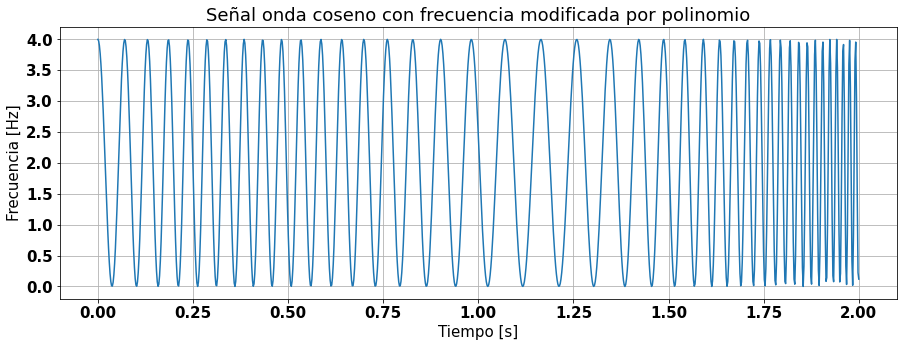

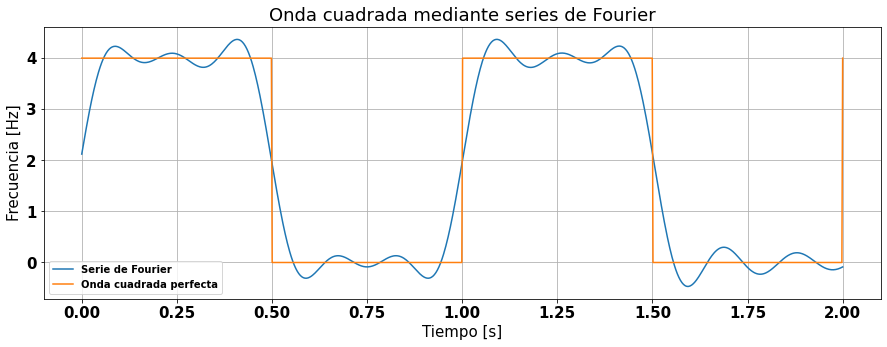

In [ ]:
# Parámetros de las señales anexas, se reutilizan parámetros previos.
import scipy.signal as signal

a = 0 # Tiempo de inicio de la señal [s].
b = 2 # Tiempo final de la señal [s].
dtp = 1000 # Cantidad de puntos para partición temporal.
fp = 1 # Frecuencia de la señal [Hz].
tp = np.linspace(a, b, dtp) # Arreglo para el tiempo de la señal.
p = np.poly1d([0.025, -0.36, 1.25, 2.0]) # Polinomio para modificar frecuencia.

sigcos = 2*(signal.sweep_poly(2*np.pi*fp*tp, p) + 1) # Señal cosenoidal con frecuencia variable, usando función de scipy.

# Generación función cuadrada con Fourier.
T = 4 # Periodicidad de la función periódica cuadrada.
sig1 = np.sin(2*np.pi*tp) # Ciclo de trabajo.
signal1 = 2*(signal.square(2*np.pi*fp*tp, duty=(sig1 + 1)/2) + 1) # Señal cuadrada perfecta.
coef= 20 # Número de coeficientes.

a0 = 2./T*simps(signal1,tp) # Cálculo de coeficientes de Fourier.
an = lambda z:2/T*simps(signal1*np.cos(2*np.pi*z*tp/T),tp)
bn = lambda z:2/T*simps(signal1*np.sin(2*np.pi*z*tp/T),tp)
# sum of the series
sigsqrf = a0/2 + sum([an(k)*np.cos(2*np.pi*k*tp/T) + bn(k)*np.sin(2*np.pi*k*tp/T) for k in range(1,coef + 1)])

# Gráfica de la señal coseno.
plt.plot(tp,sigcos)
plt.title('Señal onda coseno con frecuencia modificada por polinomio')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.grid()
plt.show()

# Gráfica de la señal cuadrada con Fourier.
plt.plot(tp,sigsqrf,label="Serie de Fourier")
plt.plot(tp,signal1,label="Onda cuadrada perfecta")
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.legend(loc='best',prop={'size':10})
plt.title("Onda cuadrada mediante series de Fourier")
plt.grid()
plt.show()

Las imágenes mostradas anteriormente corresponden a la generación de una señal coseno con una frecuencia variante dependiente de un polinomio establecido y una señal cuadrada por series de Fourier, buscando solucionar el problema de la señal cuadrada "perfecta", en la cual las discontinuidades imposibilitan el correcto desarrollo del código y presencia de resonancia paramétrica en los intervalos esperados. En este caso, la señal cosenoidal se generó usando una función de la librería *Scipy* de *Python*, mientras que la señal cuadrada se realizó al hallar la expansión de los coeficientes de Fourier por la definición tradicional de la misma, además de compararla con una función cuadrada "original". En el último caso, en pro de obtener una señal cuadrada con variación suave en el eje del tiempo, evitando las discontinuidades, se realiza la serie de Fourier con pocos coeficientes, buscando que apenas se aproxime a la forma de la función cuadrada.

En la celda posterior se presenta el código respectivo a la solución de la ecuación diferencial presentada en la sección de fundamento teórico para cada una de las funciones previamente presentadas.

Señal Coseno.
Para un n =  1 :
Existe resonancia paramétrica en algunos intervalos (puntos) de la señal.


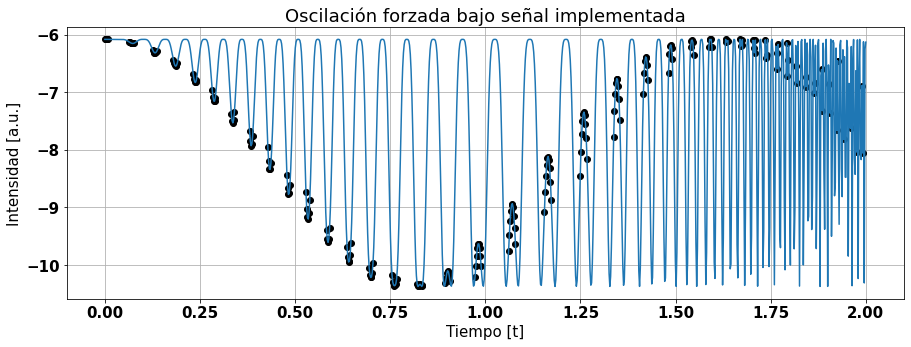

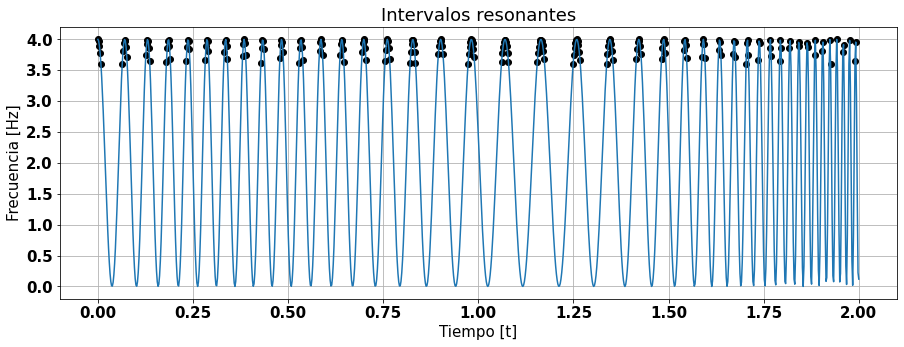

Para un n =  2 :
Existe resonancia paramétrica en algunos intervalos (puntos) de la señal.


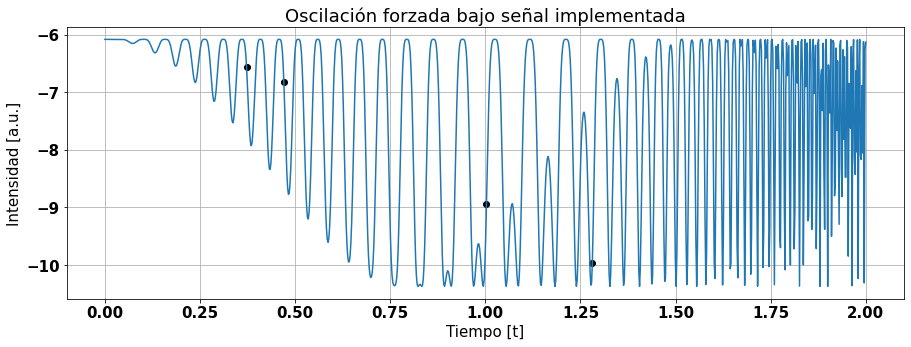

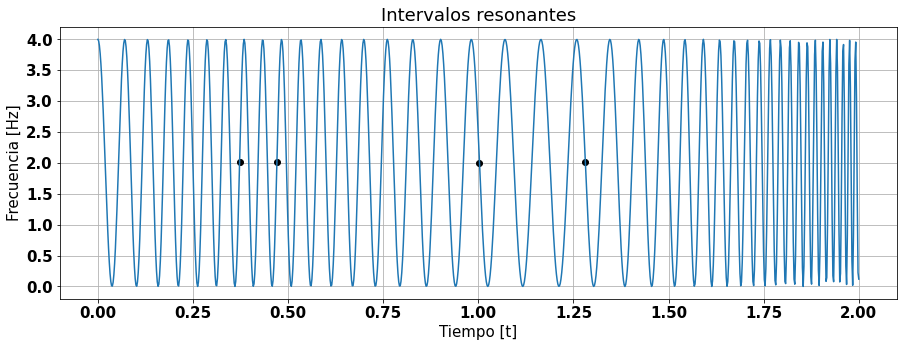

Para un n =  3 :
Existe resonancia paramétrica en algunos intervalos (puntos) de la señal.


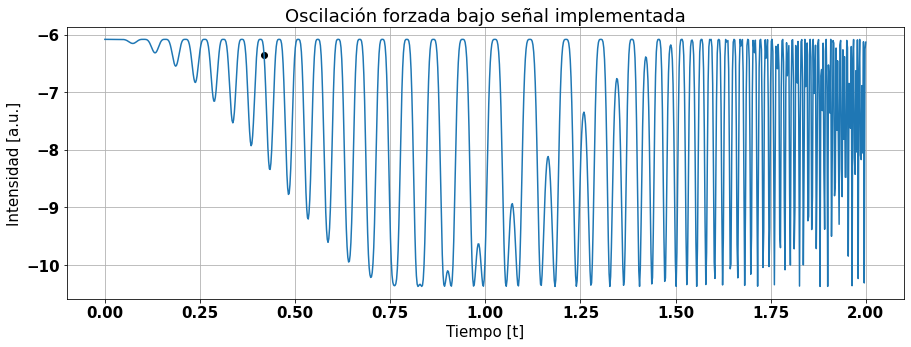

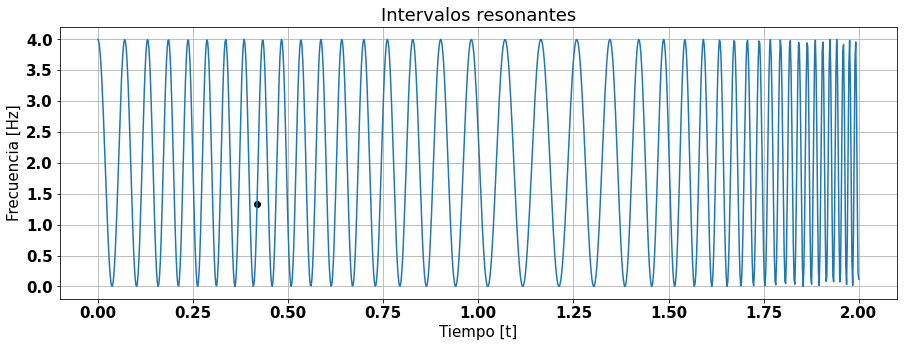

Señal Cuadrada Fourier.
Para un n =  1 :
Existe resonancia paramétrica en algunos intervalos (puntos) de la señal.


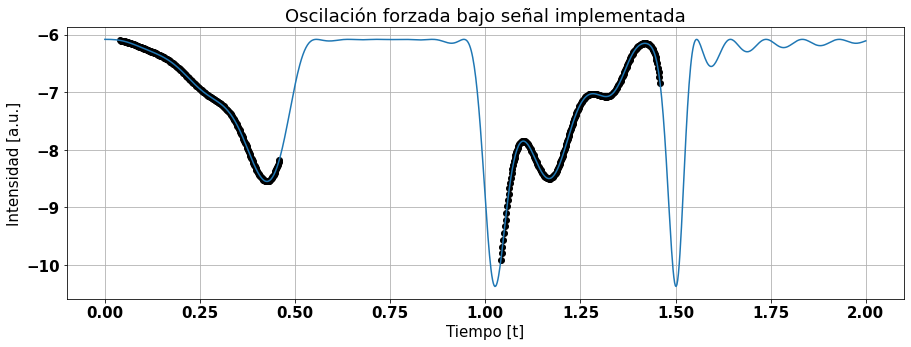

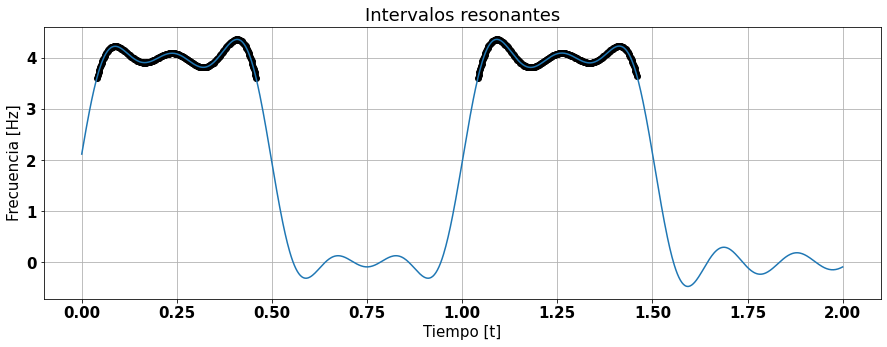

Para un n =  2 :
Existe resonancia paramétrica en algunos intervalos (puntos) de la señal.


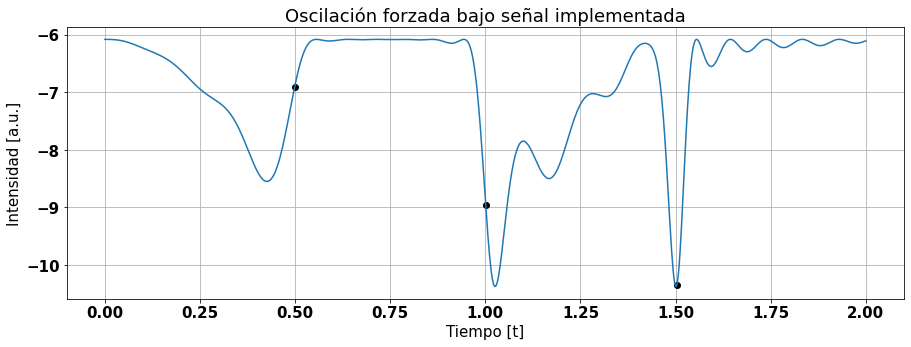

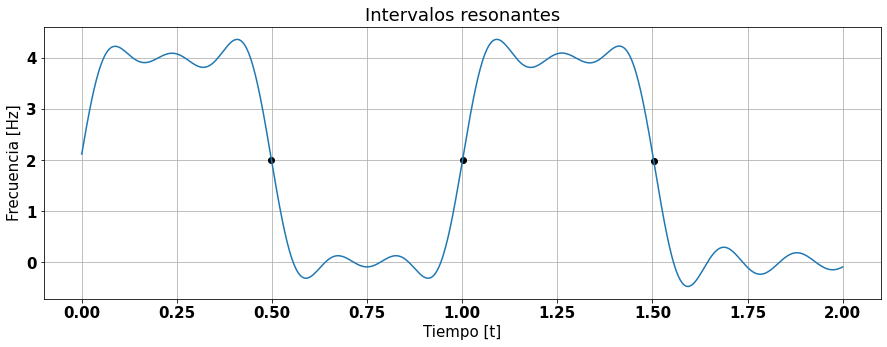

Para un n =  3 :
Bajo los parámetros ingresados no se presenta resonancia paramétrica, sólo oscilaciones puras.


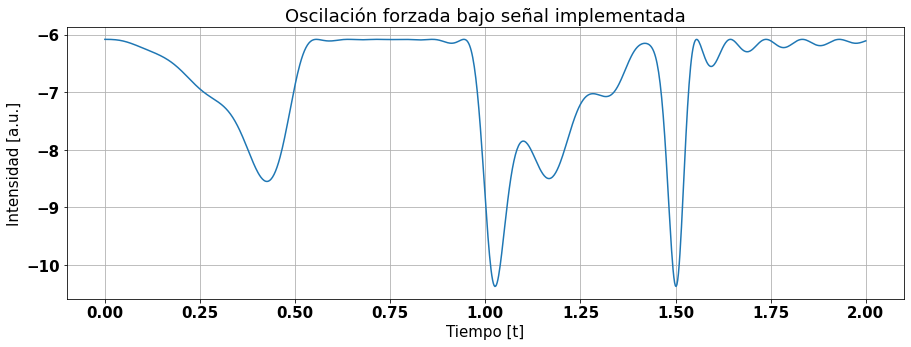

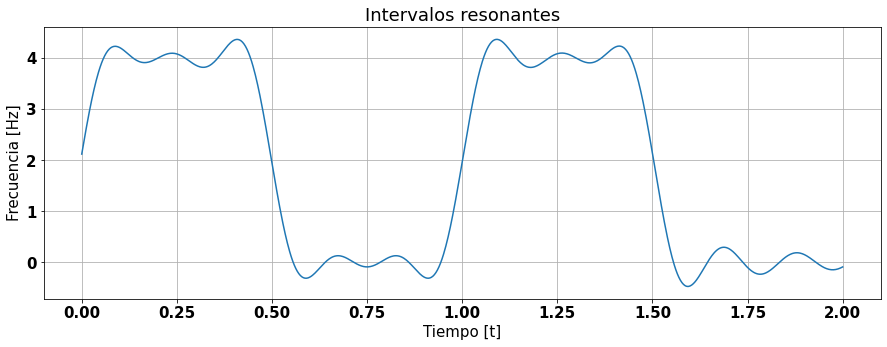

In [ ]:
# Segunda solución de ecuación diferencial en forma numérica para otras dos funciones.

signalcjt = [sigcos, sigsqrf] # Lista de señales nuevas.

# Parámetros de solución (mismos anteriores).
h = 0.2 # Constante de resonancia.
w = 2 # Frecuencia inicial.

for j in range(len(signalcjt)):
    if j==0:
        print('Señal Coseno.')
    elif j==1:
        print('Señal Cuadrada Fourier.')

    for n in range(1,4): # Probando hasta que n llega la resonancia.

        print('Para un n = ',n, ':')

        delte = (n**(2*n - 3)*(h**n)*w)/((2**(3*(n - 1)))*(factorial(n - 1))**2) # Ancho de inestabilidad.
        sol1 = [] # Lista de solución.

        for i in range(len(tp)):
            r = signalcjt[j][i] # Selección de valor de señal.
            T = tp[i] # Selección de tiempos.

            def dX_dt(X,t): # Se define la E.D.O. en forma matricial.
                return [X[1],-(w**2)*(1 + h*np.cos(r*T)*X[0])]

            X0 = [0, 0] # Condición inicial.

            # Solución numérica EDO.
            XS1 = odeint(dX_dt,X0,tp) # Función de resolución de EDO.
            XS = [] # Lista de solución.

            for i in range(len(tp)): # Creación de lista solución.
                XS.append([tp[i],XS1[i][0],XS1[i][1]])

            XS = np.array(XS)
            X = np.transpose(XS)
            sol1.append(X[1][i]) # Elementos a lista solución.

        # Gráfica de la solución.
        res1 = []
        t1 = []

        for i in range(len(sol1)): # Comprobación de existencia de resonancia.
            if  (((2*w)/n)- delte) < signalcjt[j][i] < (((2*w)/n)+delte): # Intervalo de resonancia.
                res1.append(sol1[i])
                t1.append(tp[i])

        if len(res1) == 0: # Generación de comentarios para verificar condiciones.
            print('Bajo los parámetros ingresados no se presenta resonancia paramétrica, sólo oscilaciones puras.')

        elif len(res1) >= 1:
            print('Existe resonancia paramétrica en algunos intervalos (puntos) de la señal.')

            for i in range(len(t1)):
                plt.plot(t1[i],res1[i], marker="o", color="black")

        plt.plot(tp,sol1) # Gráfica de señal tras presentar resonancia paramétrica.
        plt.xlabel('Tiempo [t]')
        plt.ylabel('Intensidad [a.u.]')
        plt.grid()
        plt.title('Oscilación forzada bajo señal implementada')
        plt.show()

        # Gráfica de la señal original indicando aquellos valores que presentan resonancia paramétrica.
        res = []
        t2 = []

        for i in range(len(signalcjt[j])):
            if  (((2*w)/n) -delte) < signalcjt[j][i] < (((2*w)/n) + delte):
                res.append(signalcjt[j][i])
                t2.append(tp[i])

        for i in range(len(t1)):
            plt.plot(t2[i],res[i], marker="o", color="black")

        plt.plot(tp,signalcjt[j])
        plt.xlabel('Tiempo [t]')
        plt.grid()
        plt.ylabel('Frecuencia [Hz]')
        plt.title('Intervalos resonantes')
        plt.show()

De forma somera, la discusión respecto a las figuras presentadas en la celda previa gira en torno a la diferenciación con los resultados obtenidos en la primera sección del presente cuaderno. En el caso de la señal coseno se observa adecuadamente la resonancia paramétrica y los intervalos que la producen, reduciéndose estos conforme aumenta $n$, más sin agotarse hasta el $n$ tomado; los puntos graficados en negro muestran cierta periodicidad, debido a la forma periódica de la función original, así como la posición de estos, que varía de acuerdo a la relación $\frac{2\omega_0}{n}$. Conforme se aumenta $n$ deberían aparecer periódicamente los intervalos de resonancia, sin embargo, debido a algún error en el código esto no sucede de forma explícita.

Por otro lado, para la señal cuadrada generada por series de Fourier, se presencia una mejoría considerable respecto al análisis original. En este caso se presenta resonancia hasta un $n=2$, cumpliendo con las mismas características mencionadas previamente, pero para la onda actual. En $n\geq 3$ la resonancia paramétrica desaparece, en tanto ya se alcanzan valores muy pequeños en los intervalos como para ser tomados; esto podría mejorar tomando una mayor cantidad de puntos de muestreo, pero ello produciría un aumento considerable en el tiempo de compilación del código. Nuevamente se reitera que usando otro tipo de funciones periódicas se pueden observar resultados análogos, los cuales dependerán de los parámetros utilizados.

### Conclusiones.

En general, se puede concluir que las oscilaciones paramétricas funcionan bien en tanto la función de la señal forzante periódica no presente discontinuidades severas, lo cual evitará que los intervalos del ancho de inestabilidad sean exactos, perdiendo así información. Al aplicar distintos tipos de señales se observa la oscilación paramétrica, la cual disminuye conforme $n$ aumenta, y depende netamente de los parámetros seleccionados para $\omega_0$ y $h$, cuya elección puede ser arbitraria pero basada en el fundamento teórico de la misma.

### Bibliografía.

**[1]** Landau, Lev Davidovich, and E. M. Lifshitz. Física teórica. Mecánica. Vol. 1. Reverte, 1970.

**[2]** Mahecha, Jorge. Mecánica clásica Avanzada. Universidad de Antioquia, 2006.